Enter number of bits (n) to visualize [e.g. 2, 3, 4, 6, 8]: 3

RESULTS FOR n = 3 BITS (L = 8 Levels)
Step size (Delta)     : 0.250000
Mean Squared Error    : 6.160347e-03
Simulated SQNR        : 19.09 dB
Theoretical SQNR      : 19.82 dB
First 5 PCM Codewords : ['100', '100', '100', '100', '100']



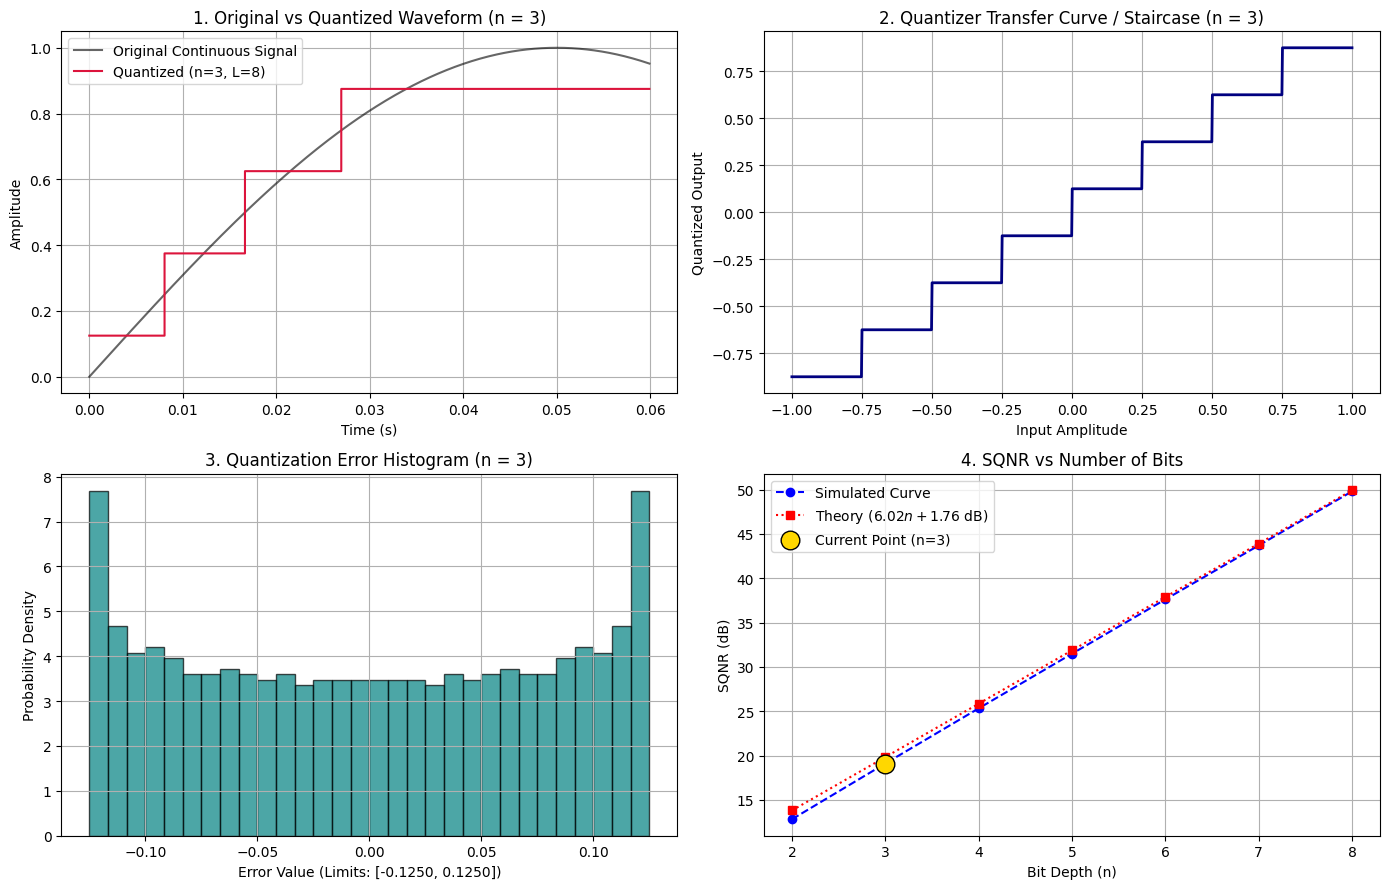

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. UNIFORM PCM QUANTIZER
# ==========================================
def uniform_pcm_quantizer(x, n_bits, x_min=-1.0, x_max=1.0):
    L = 2 ** n_bits
    delta = (x_max - x_min) / L

    quant_levels = x_min + (np.arange(L) + 0.5) * delta
    indices = np.floor((x - x_min) / delta).astype(int)
    indices = np.clip(indices, 0, L - 1)

    pcm_codewords = [np.binary_repr(idx, width=n_bits) for idx in indices]
    x_quantized = quant_levels[indices]

    return x_quantized, indices, pcm_codewords, delta

# ==========================================
# 2. SIGNAL SETUP
# ==========================================
fs = 10000
f_signal = 5
t = np.linspace(0, 1, fs, endpoint=False)
x = np.sin(2 * np.pi * f_signal * t)
p_signal = np.mean(x ** 2)

# ==========================================
# 3. INTERACTIVE BIT INPUT (Aap yahan choose kar sakte hain)
# ==========================================
user_val = input("Enter number of bits (n) to visualize [e.g. 2, 3, 4, 6, 8]: ").strip()
n_demo = int(user_val) if user_val != "" else 3

# Selected bit calculation
x_q, indices, codewords, delta = uniform_pcm_quantizer(x, n_demo)
error = x - x_q
mse = np.mean(error ** 2)
sqnr_sim = 10 * np.log10(p_signal / mse)
sqnr_theory = 6.02 * n_demo + 1.76

print("\n" + "=" * 45)
print(f"RESULTS FOR n = {n_demo} BITS (L = {2**n_demo} Levels)")
print("=" * 45)
print(f"Step size (Delta)     : {delta:.6f}")
print(f"Mean Squared Error    : {mse:.6e}")
print(f"Simulated SQNR        : {sqnr_sim:.2f} dB")
print(f"Theoretical SQNR      : {sqnr_theory:.2f} dB")
print(f"First 5 PCM Codewords : {codewords[:5]}")
print("=" * 45 + "\n")

# ==========================================
# 4. DYNAMIC 4-PANEL VISUALIZATION
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(14, 9))

# Plot 1: Waveform for chosen n
axs[0, 0].plot(t[:600], x[:600], label='Original Continuous Signal', color='black', alpha=0.6)
axs[0, 0].step(t[:600], x_q[:600], where='mid', label=f'Quantized (n={n_demo}, L={2**n_demo})', color='crimson', linewidth=1.5)
axs[0, 0].set_title(f'1. Original vs Quantized Waveform (n = {n_demo})')
axs[0, 0].set_xlabel('Time (s)')
axs[0, 0].set_ylabel('Amplitude')
axs[0, 0].grid(True)
axs[0, 0].legend()

# Plot 2: Staircase for chosen n
x_ramp = np.linspace(-1, 1, 1000)
x_ramp_q, _, _, _ = uniform_pcm_quantizer(x_ramp, n_bits=n_demo)
axs[0, 1].plot(x_ramp, x_ramp_q, color='navy', linewidth=2)
axs[0, 1].set_title(f'2. Quantizer Transfer Curve / Staircase (n = {n_demo})')
axs[0, 1].set_xlabel('Input Amplitude')
axs[0, 1].set_ylabel('Quantized Output')
axs[0, 1].grid(True)

# Plot 3: Error Histogram for chosen n
axs[1, 0].hist(error, bins=30, density=True, color='teal', alpha=0.7, edgecolor='black')
axs[1, 0].set_title(f'3. Quantization Error Histogram (n = {n_demo})')
axs[1, 0].set_xlabel(f'Error Value (Limits: [{-delta/2:.4f}, {delta/2:.4f}])')
axs[1, 0].set_ylabel('Probability Density')
axs[1, 0].grid(True)

# Plot 4: SQNR benchmark curve with CURRENT point highlighted
all_bits = [2, 3, 4, 5, 6, 7, 8]
sim_sqnr_all = [10 * np.log10(p_signal / np.mean((x - uniform_pcm_quantizer(x, b)[0])**2)) for b in all_bits]
theory_sqnr_all = [6.02 * b + 1.76 for b in all_bits]

axs[1, 1].plot(all_bits, sim_sqnr_all, 'o--', color='blue', label='Simulated Curve')
axs[1, 1].plot(all_bits, theory_sqnr_all, 's:', color='red', label='Theory ($6.02n + 1.76$ dB)')
# Current point highlight
axs[1, 1].scatter([n_demo], [sqnr_sim], color='gold', s=180, edgecolors='black', zorder=5, label=f'Current Point (n={n_demo})')
axs[1, 1].set_title('4. SQNR vs Number of Bits')
axs[1, 1].set_xlabel('Bit Depth (n)')
axs[1, 1].set_ylabel('SQNR (dB)')
axs[1, 1].set_xticks(all_bits)
axs[1, 1].grid(True)
axs[1, 1].legend()

plt.tight_layout()
plt.show()